# 02 — Predictive Model Benchmarks

In [1]:
from pathlib import Path
import json
import os
import sys

def find_project_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "src").is_dir() and (candidate / "configs").is_dir():
            return candidate
    for base in (Path("/kaggle/working"), Path("/kaggle/input")):
        if base.exists():
            matches = list(base.glob("**/configs/ieee_cis.yaml"))
            if matches:
                return matches[0].parents[1]
    raise FileNotFoundError("Project root with src/ and configs/ was not found")

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

QUICK_RUN = os.getenv("THESIS_QUICK_RUN", "1") == "1"
ALLOW_SYNTHETIC_FALLBACK = os.getenv("THESIS_SYNTHETIC_FALLBACK", "1") == "1"
DATASET_NAME = os.getenv("THESIS_DATASET", "ieee_cis").lower()
KAGGLE = Path("/kaggle").exists()
OUTPUT_BASE = Path("/kaggle/working/thesis_outputs") if KAGGLE else PROJECT_ROOT / "results/runs/notebooks"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 120)
print({"project_root": str(PROJECT_ROOT), "dataset": DATASET_NAME, "quick_run": QUICK_RUN, "kaggle": KAGGLE})

{'project_root': 'E:\\Study\\Thực tập tốt nghiệp\\Explainable_NeuroSymbolic_Fraud_Detection', 'dataset': 'ieee_cis', 'quick_run': True, 'kaggle': False}


## Thiết lập

- PR-AUC is the primary metric.
- F2 is the default operating-threshold objective.
- Quick mode is for execution checks, not final reporting.

In [2]:
from src.experiment import run_predictive_benchmarks

if DATASET_NAME not in {"ieee_cis", "baf"}:
    raise ValueError(f"Unsupported dataset: {DATASET_NAME}")
output_dir = OUTPUT_BASE / f"02_predictive_benchmarks_{DATASET_NAME}"
result = run_predictive_benchmarks(
    PROJECT_ROOT / "configs" / f"{DATASET_NAME}.yaml",
    output_dir=output_dir,
    model_names=("mlp", "tabular_resnet", "tree"),
    quick_run=QUICK_RUN,
    synthetic_fallback=ALLOW_SYNTHETIC_FALLBACK,
)
metrics = result["metrics"]
print({"data_source": result["data_source"], "output_dir": str(output_dir)})
display(metrics.round(4))

E:\Study\Thực tập tốt nghiệp\Explainable_NeuroSymbolic_Fraud_Detection\src\training\trainer.py:47: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  torch.as_tensor(y, dtype=torch.float32),


{'data_source': 'synthetic', 'output_dir': 'E:\\Study\\Thực tập tốt nghiệp\\Explainable_NeuroSymbolic_Fraud_Detection\\results\\runs\\notebooks\\02_predictive_benchmarks_ieee_cis'}


,model,model_key,split,pr_auc,roc_auc,precision,recall,f1,fbeta,brier,ece,nll,threshold,positive_rate
0,MLP,mlp,validation,0.2862,0.8037,0.3231,0.3962,0.3559,0.3791,0.1922,0.3946,0.5736,0.7284,0.0361
1,MLP,mlp,test,0.2658,0.6490,0.2895,0.2750,0.2821,0.2778,0.1903,0.4004,0.5692,0.7284,0.0211
2,TabularResNet,tabular_resnet,validation,0.2583,0.7776,0.3922,0.3774,0.3846,0.3802,0.4268,0.6151,1.1237,0.9240,0.0283
3,TabularResNet,tabular_resnet,test,0.2602,0.7134,0.3333,0.2500,0.2857,0.2632,0.3654,0.5706,0.9656,0.9240,0.0167
4,xgboost,tree,validation,0.1949,0.6177,0.1132,0.3396,0.1698,0.2426,0.0750,0.1858,0.2936,0.4197,0.0883
5,xgboost,tree,test,0.2252,0.6645,0.0667,0.2750,0.1073,0.1692,0.0682,0.1882,0.2727,0.4197,0.0917


## Data

In [3]:
prepared = result["prepared"]
data_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(prepared.y_train), len(prepared.y_validation), len(prepared.y_test)],
    "fraud_rate": [prepared.y_train.mean(), prepared.y_validation.mean(), prepared.y_test.mean()],
})
display(data_summary)

,split,rows,fraud_rate
0,train,8400,0.024881
1,validation,1800,0.029444
2,test,1800,0.022222


## Results

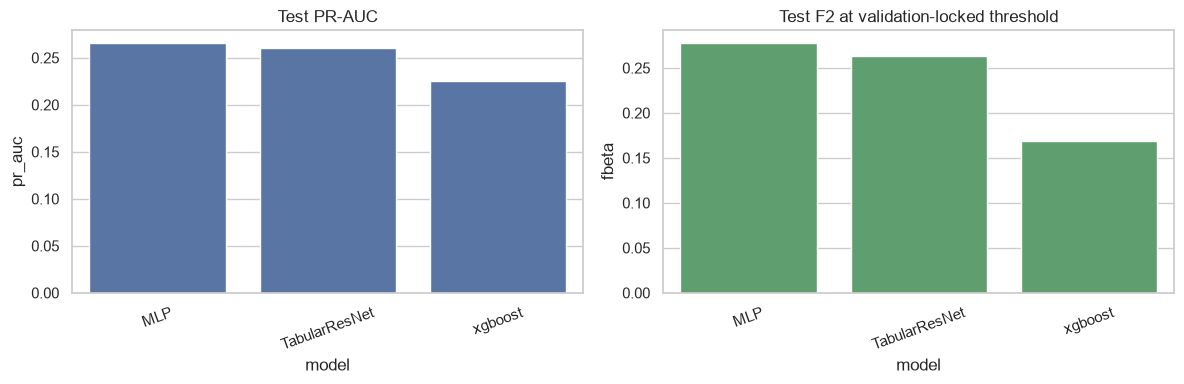

In [4]:
test_metrics = metrics.query("split == 'test'").copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=test_metrics, x="model", y="pr_auc", ax=axes[0], color="#4C72B0")
axes[0].set_title("Test PR-AUC")
axes[0].tick_params(axis="x", rotation=20)
sns.barplot(data=test_metrics, x="model", y="fbeta", ax=axes[1], color="#55A868")
axes[1].set_title("Test F2 at validation-locked threshold")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
fig.savefig(output_dir / "predictive_model_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

In [5]:
for model_name, history in result["histories"].items():
    history_frame = pd.DataFrame(history)
    display(Markdown(f"### {model_name} training history"))
    display(history_frame)

### mlp training history

,epoch,train_loss,validation_pr_auc,learning_rate
0,1.0,1.520587,0.281437,0.000975
1,2.0,1.256335,0.284447,0.000381
2,3.0,1.209438,0.286216,0.000007


### tabular_resnet training history

,epoch,train_loss,validation_pr_auc,learning_rate
0,1.0,1.463082,0.258304,0.000975
1,2.0,1.325611,0.245463,0.000381
2,3.0,1.129431,0.252589,0.000007


## Takeaways

In [6]:
best = test_metrics.sort_values("pr_auc", ascending=False).iloc[0]
display(Markdown(
    f"- Data source: **{result['data_source']}**.\n"
    f"- Highest test PR-AUC in this run: **{best['model']} = {best['pr_auc']:.4f}**.\n"
    f"- Its locked-threshold F2 is **{best['fbeta']:.4f}**.\n"
    "- Interpret only real-data, non-quick runs as thesis evidence."
))

- Data source: **synthetic**.
- Highest test PR-AUC in this run: **MLP = 0.2658**.
- Its locked-threshold F2 is **0.2778**.
- Interpret only real-data, non-quick runs as thesis evidence.